In [31]:
from momentfm import MOMENTPipeline
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large", 
    model_kwargs={"task_name": "embedding"},  # For anomaly detection, we will load MOMENT in `reconstruction` mode
    # local_files_only=True,  # Whether or not to only look at local files (i.e., do not try to download the model).
)
model.init()
model.to('cuda')
model.eval()

/home/louis/cd_project/.pixi/envs/momentfm/lib/python3.11/site-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


MOMENTPipeline(
  (normalizer): RevIN()
  (tokenizer): Patching()
  (patch_embedding): PatchEmbedding(
    (value_embedding): Linear(in_features=8, out_features=1024, bias=False)
    (position_embedding): PositionalEmbedding()
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 1024)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=1024, out_features=1024, bias=False)
              (k): Linear(in_features=1024, out_features=1024, bias=False)
              (v): Linear(in_features=1024, out_features=1024, bias=False)
              (o): Linear(in_features=1024, out_features=1024, bias=False)
              (relative_attention_bias): Embedding(32, 16)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
  

In [33]:
from data.datasets import load_experiment, load_episodes
from utils.windows import strided_window_view
import numpy as np

w = 100

x_tr, x_te, y_true, _ = load_experiment('ant', win=w, max_train_eps=1000)
x_tr.shape, x_te.shape, y_true.shape

x_tr = strided_window_view(x_tr, window=w, stride=w).reshape((-1, w, 27))
x_tr.shape, x_te.shape, y_true.shape

((10000, 100, 27), (923, 100, 27), (923,))

In [34]:
def embed(
    model, 
    x,  # (N, T, C)
    batch_size=64, 
    context=512
):
    device = next(model.parameters()).device
    x = torch.as_tensor(x, dtype=torch.float32)
    N, L, C = x.shape
    assert L <= context

    # MOMENT expects (B, C, T) with T = context
    x = x.permute(0, 2, 1)  # (N, C, L)
    if L < context:
        x = torch.nn.functional.pad(x, (0, context - L))

    mask = torch.zeros(N, context, dtype=torch.float32)
    mask[:, :L] = 1.0

    parts = []
    with torch.no_grad():
        for i in range(0, N, batch_size):
            xb = x[i:i + batch_size].to(device)
            mb = mask[i:i + batch_size].to(device)
            z = model(x_enc=xb, input_mask=mb, reduction="none").embeddings.mean(dim=2)
            parts.append(z.cpu())
    return torch.cat(parts)

In [ ]:
z_tr = embed(model, x_tr)
z_te = embed(model, x_te)

z_tr /= z_tr.norm(dim=-1, keepdim=True)
z_te /= z_te.norm(dim=-1, keepdim=True)

In [ ]:
z_tr.shape

## Cosine

In [139]:
from sklearn.manifold import MDS
from utils.plotting import plot_gram

In [140]:
k_tr = z_tr @ z_tr.T
k_te = z_te @ z_te.T
k = z_tr @ z_te.T

/tmp/ipykernel_2862420/2414018523.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  k_tr = z_tr @ z_tr.T


RuntimeError: The size of tensor a (10) must match the size of tensor b (1024) at non-singleton dimension 0

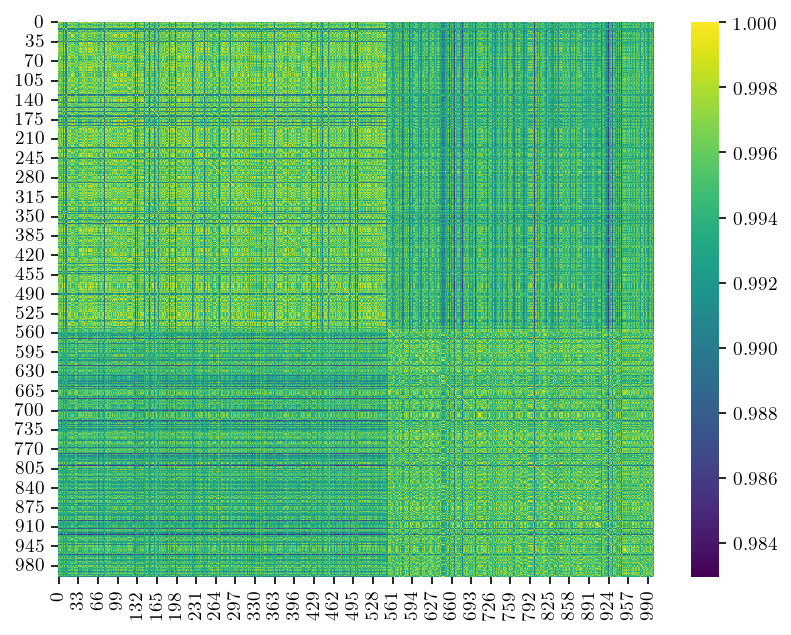

In [113]:
plot_gram(k_te, y_true)

In [114]:
from algs.kern_cd import KernCD
from algs.kernels import RBF
from sklearn.metrics import roc_auc_score

In [115]:
kernel = RBF().fit(z_tr)
p = KernCD(kernel).fit(z_tr)
y_pred = p.predict(z_te)

0.900616794288582

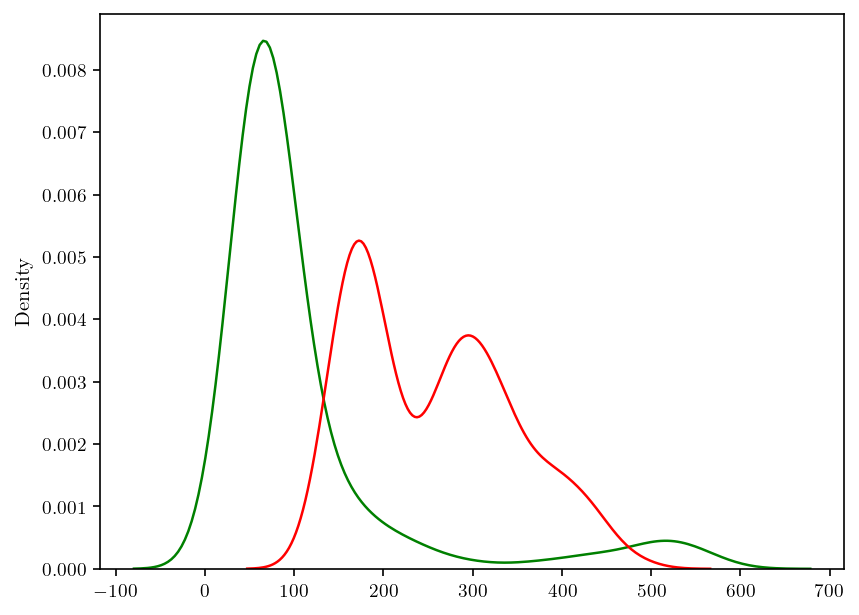

In [116]:
sns.kdeplot(y_pred[~y_true], color='green')
sns.kdeplot(y_pred[y_true], color='red')

roc_auc_score(y_true, y_pred)

## RND

In [14]:
from sklearn.metrics import roc_auc_score

In [7]:
class RND(torch.nn.Module):
    def __init__(self, embed_dim=1024, out_dim=256):
        super().__init__()
        self.target = torch.nn.Sequential(
            torch.nn.Linear(embed_dim, 1024),
            torch.nn.LeakyReLU(),
            torch.nn.Linear(1024, 2048),
            torch.nn.LeakyReLU(),
            torch.nn.Linear(2048, 4096),
            torch.nn.LeakyReLU(),
            torch.nn.Linear(4096, out_dim),
        )
        self.predictor = torch.nn.Sequential(
            torch.nn.Linear(embed_dim, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 2048),
            torch.nn.ReLU(),
            torch.nn.Linear(2048, 4096),
            torch.nn.ReLU(),
            torch.nn.Linear(4096, 2048),
            torch.nn.ReLU(),
            torch.nn.Linear(2048, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, out_dim),
        )
        for p in self.target.parameters():
            p.requires_grad = False

    def forward(self, z):
        """z: (B, C, embed_dim). Returns (B, C) per-channel errors."""
        B, C, D = z.shape
        z_flat = z.reshape(B * C, D)
        with torch.no_grad():
            t = self.target(z_flat)
        p = self.predictor(z_flat)
        err = (t - p).pow(2).sum(dim=-1)
        return err.reshape(B, C)

In [27]:
def train_rnd(rnd, z_tr, epochs=10, lr=1e-3, batch_size=256, val_frac=0.1):
    """z_tr: (N, C, embed_dim) tensor or numpy."""
    device = next(rnd.parameters()).device
    z = torch.as_tensor(z_tr, dtype=torch.float32)

    n_val = int(len(z) * val_frac)
    perm = torch.randperm(len(z))
    z_val = z[perm[:n_val]]
    z = z[perm[n_val:]]

    opt = torch.optim.Adam(rnd.predictor.parameters(), lr=lr)

    for epoch in tqdm(range(epochs)):
        perm = torch.randperm(len(z))
        total_loss = 0
        for i in range(0, len(z), batch_size):
            batch = z[perm[i:i + batch_size]].to(device)
            loss = rnd(batch).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
        if (epoch + 1) % 20 == 0:
            with torch.no_grad():
                val_loss = rnd(z_val.to(device)).mean().item()
            print(f"epoch {epoch+1}: train={total_loss:.4f} val={val_loss:.4f}")


@torch.no_grad()
def score_rnd(rnd, z, batch_size=256):
    """z: (N, C, embed_dim) tensor or numpy. Returns (N,) anomaly scores."""
    device = next(rnd.parameters()).device
    z = torch.as_tensor(z, dtype=torch.float32)
    scores = []
    for i in range(0, len(z), batch_size):
        batch = z[i:i + batch_size].to(device)
        scores.append(rnd(batch).mean(dim=1).cpu())
    return torch.cat(scores).numpy()

In [ ]:
rnd = RND().cuda()
train_rnd(rnd, z_tr, epochs=250, lr=1e-4)

  8%|██▋                               | 20/250 [00:16<03:09,  1.21it/s]

epoch 20: train=0.0010 val=0.0000


 12%|███▉                              | 29/250 [00:23<03:01,  1.21it/s]

In [ ]:
y_pred = score_rnd(rnd, z_te)

In [ ]:
sns.kdeplot(y_pred[~y_true], color='green')
sns.kdeplot(y_pred[y_true], color='red')

roc_auc_score(y_true, y_pred)

In [ ]:
# Average over patches: (N, C, n_patches, D) -> (N, C, D)
z_tr_chan = z_tr.mean(axis=2).numpy()
z_te_chan = z_te.mean(axis=2).numpy()

rnd = RND().cuda()
train_rnd(rnd, z_tr_chan)
scores = score_rnd(rnd, z_te_chan)

sns.kdeplot(scores[~y_true[:len(scores)]], color='green', label='Normal')
sns.kdeplot(scores[y_true[:len(scores)]], color='red', label='Anomaly')
plt.legend()
print(f"RND AUC: {roc_auc_score(y_true[:len(scores)], scores):.4f}")